# Análise de Inferência Causal usando DoWhy

Este notebook carrega o conjunto de dados em `data/processed/farms.csv`, importa a definição do DAG causal do arquivo `model/causal_dag.py` e executa tarefas de inferência causal utilizando a biblioteca **DoWhy** para analisar qual cluster de dieta das fazendas oferece o melhor trade-off produtividade e emissões entéricas (buscando maior produtividade e menor emissões).

In [10]:
import os
import sys
import re
import pandas as pd
import numpy as np
import dowhy
from dowhy import CausalModel

# Garante que o diretório de execução seja a raiz do projeto para localizar os arquivos corretamente
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Exibir todas as colunas do dataset
pd.set_option('display.max_columns', None)

## 1. Carregando os Dados

In [11]:
df = pd.read_csv('data/processed/farms.csv', sep=';')
print(f"Dimensões do dataset: {df.shape}")
df.head()

Dimensões do dataset: (50, 39)


,Property_Name,Location,Owner_Name,Information_Responsible,Predominant_Soil_Type,Lactating_Cows,Dry_Cows,Heifers,Calves,Bulls,Lactating_Cows_Weight,Dry_Cows_Weight,Heifers_Weight,Calves_Weight,Bulls_Weight,Females,Males,Cows_Discarded_Per_Year,Discarded_Cows_Destination,Productivity,Total_Milk_Production,Milk_Protein_Percentage,Milk_Fat_Percentage,Total,DMI_Check,Diesel,Gasoline,Other_Fuel,Electricity_Grid,Photovoltaic_Energy,Pasture_Area,Non_Organic_Fertilizer,Organic_Fertilizer,co2_enteric_fermentation,co2_manure_management,co2_fertilizer_emissions,co2_energy_emissions,co2_total_emissions,Dietary_Strategy_Cluster
0,BR – 1,Santa Catarina,Anonymous,Anonymous,Latossolo Vermelho-Amarelo,13.0,4.0,8.0,15.0,0.0,500.0,530.0,320.0,150.0,0.0,0.0,0.0,4.0,venda,15.465629,73384.41,3.32,4.13,88410.30,88410.30,0.0,0.0,0.0,2500.0,0.0,3.0,2304.0,0.0,51000.0,3471.45,7209.2160,582.5,62263.1660,0
1,BR – 2,Santa Catarina,Anonymous,Anonymous,Latossolo Vermelho-Amarelo,26.0,5.0,12.0,19.0,0.0,500.0,530.0,320.0,150.0,0.0,0.0,0.0,15.0,venda,17.117211,162442.33,3.19,3.96,215423.00,215423.00,2000.0,0.0,0.0,9600.0,0.0,3.5,455.0,0.0,89750.0,6116.70,1423.6950,7596.8,104887.1950,1
2,BR – 3,Santa Catarina,Anonymous,Anonymous,Latossolo Vermelho-Amarelo,30.0,6.0,20.0,27.0,0.0,500.0,530.0,320.0,150.0,0.0,0.0,0.0,12.0,venda,22.772406,249357.85,2.96,3.35,291996.35,291996.35,2000.0,0.0,0.0,12000.0,0.0,4.0,854.0,0.0,111000.0,7537.35,2672.1660,8156.0,129365.5160,1
3,BR – 4,Santa Catarina,Anonymous,Anonymous,Latossolo Vermelho-Amarelo,32.0,10.0,12.0,9.0,0.0,500.0,530.0,320.0,150.0,0.0,0.0,0.0,9.0,venda,16.757430,195726.78,3.48,4.20,138356.90,138356.90,600.0,0.0,0.0,9600.0,0.0,4.0,696.0,0.0,106000.0,7598.45,2177.7840,3844.8,119621.0340,2
4,BR – 5,Santa Catarina,Anonymous,Anonymous,Latossolo Vermelho-Amarelo,30.0,4.0,13.0,20.0,0.0,500.0,530.0,320.0,150.0,0.0,0.0,0.0,5.0,venda,19.967890,218648.40,3.31,3.92,290445.10,290445.10,0.0,0.0,0.0,12000.0,0.0,3.0,433.5,0.0,99750.0,6743.20,1356.4215,2796.0,110645.6215,2


# 2. Importando o grafo causal de model/causal_dag.py

In [12]:
from model.causal_dag import causal_graph

## 3. Inicializando os Modelos Causais no DoWhy

Instanciamos 2 `CausalModel`'s:
Em ambos usamos
- **Dados (data):** Nossos dados importados
- **Tratamento (Treatment):** `Dietary_Strategy_Cluster` (perfil de estratégia dietética)
- **Gráfico Causal (Graph):** nosso grafo causal importado acima

Criamos dois modelos, pois cada um considera uma variável-alvo como saída (Y), portanto
- **Desfecho (Outcome):** `co2_enteric_fermentation` (emissões relacionadas à fermentação entérica) ou `Productivity` (produtividade dos animais medidas em L por animal)

As variáveis presentes no DAG mas ausentes no arquivo CSV (`Cattle_Breed`, `Production_System`) serão automaticamente tratadas como variáveis não observadas (confounders latentes) pelo DoWhy.

In [13]:
# Troca o tipo de variável de cluster para não ser interpretada como numérica contínua
df['Dietary_Strategy_Cluster'] = df['Dietary_Strategy_Cluster'].astype(str)

model_emissions = CausalModel(
    data=df,
    treatment='Dietary_Strategy_Cluster',
    outcome='co2_enteric_fermentation',
    graph=causal_graph   
)

model_prod = CausalModel(
    data=df,
    treatment='Dietary_Strategy_Cluster',
    outcome='Productivity',
    graph=causal_graph   
)


/home/vscode/.local/lib/python3.11/site-packages/dowhy/causal_model.py:581: UserWarning: 2 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(


# 4. Estimando efeitos com perguntas contra-factuais

Queremos simular com base em causalidade e dados uma "intervenção universal" hipotética, isto é, para cada cluster de dieta (0, 1, 2, 3), vamos perguntar ao modelo: "Quais resultados de produtividade e emissões obteríamos se todas as fazendas do dataset adotassem essa dieta, mantendo todos seus outros dados?". Com isso, nosso objetivo é extrair os resultados causais: O DoWhy calculará o valor esperado causal para a Produtividade $E[\text{Productivity} \vert{} do(\text{Cluster}=k)]$ e para as emissões $E[\text{co2\_enteric\_fermentation} \vert{} do(\text{Cluster}=k)]$ para que calculemos o Trade-Off.

In [14]:
# Para as perguntas que queremos, usaremos a API GCM do DoWhy
import networkx as nx
import dowhy.gcm as gcm

# A API GCM precisa do grafo no formato do networkx (usamos o data represented, que contém apenas as variáveis que temos no dataset)
# Faltam dados para Cattle_Breed e Production_System
causal_model = gcm.InvertibleStructuralCausalModel(nx.DiGraph(nx.nx_pydot.read_dot('model/causal_dag_datarepresented.dot')))

In [15]:
import dowhy.gcm as gcm
from pprint import pprint

np.random.seed(42)

# Mapeamento Topológico Manual (Bypass de Cross-Validation)
for node in causal_model.graph.nodes:
    predessores = list(causal_model.graph.predecessors(node))
    
    # Nós Raiz (Variáveis que não recebem setas)
    if len(predessores) == 0:
        causal_model.set_causal_mechanism(node, gcm.EmpiricalDistribution())
        continue
        
    if not pd.api.types.is_numeric_dtype(df[node]):
        causal_model.set_causal_mechanism(
            node, 
            # Usamos o wrapper nativo do DoWhy que já lida com categorias perfeitamente
            gcm.ClassifierFCM(gcm.ml.create_random_forest_classifier())
        )
    # Se a coluna for estritamente numérica (float, int)
    else:
        causal_model.set_causal_mechanism(
            node, 
            gcm.AdditiveNoiseModel(gcm.ml.create_linear_regressor())
        )

# Ajuste Paramétrico Final
gcm.fit(causal_model, df)

results = {}

for cluster in sorted(df['Dietary_Strategy_Cluster'].unique()):
    samples = gcm.interventional_samples(
        causal_model,
        interventions={'Dietary_Strategy_Cluster': lambda x, c=cluster: c},
        num_samples_to_draw=1000
    )

    prod_absolute_mean = samples['Productivity'].mean()
    emissions_absolute_mean = samples['co2_enteric_fermentation'].mean()

    ratio = prod_absolute_mean / emissions_absolute_mean if emissions_absolute_mean != 0 else 0

    results[cluster] = {
        'Productivity': prod_absolute_mean,
        'Emissions': emissions_absolute_mean,
        'Ratio': ratio
    }

pprint(results)

Fitting causal mechanism of node Dietary_Strategy_Cluster: 100%|██████████| 31/31 [00:00<00:00, 121.74it/s]


{'0': {'Emissions': np.float64(113355.74999999993),
       'Productivity': np.float64(15.87543081172257),
       'Ratio': np.float64(0.00014004962969873676)},
 '1': {'Emissions': np.float64(118764.25000000001),
       'Productivity': np.float64(22.99625523650334),
       'Ratio': np.float64(0.00019362944014300043)},
 '2': {'Emissions': np.float64(115448.74999999999),
       'Productivity': np.float64(16.429783213960558),
       'Ratio': np.float64(0.00014231235257168708)},
 '3': {'Emissions': np.float64(122475.75000000006),
       'Productivity': np.float64(19.338823063862776),
       'Ratio': np.float64(0.00015789920097539935)}}


--- RESUMO DO TRADE-OFF CAUSAL (CENÁRIOS ABSOLUTOS) ---


,Cluster,Productivity,Emissions,Ratio (x10k)
0,0,15.88,"113,355.75 kg CO2eq",1.40
1,1,23.00,"118,764.25 kg CO2eq",1.94
2,2,16.43,"115,448.75 kg CO2eq",1.42
3,3,19.34,"122,475.75 kg CO2eq",1.58


/tmp/ipykernel_381/3992610623.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


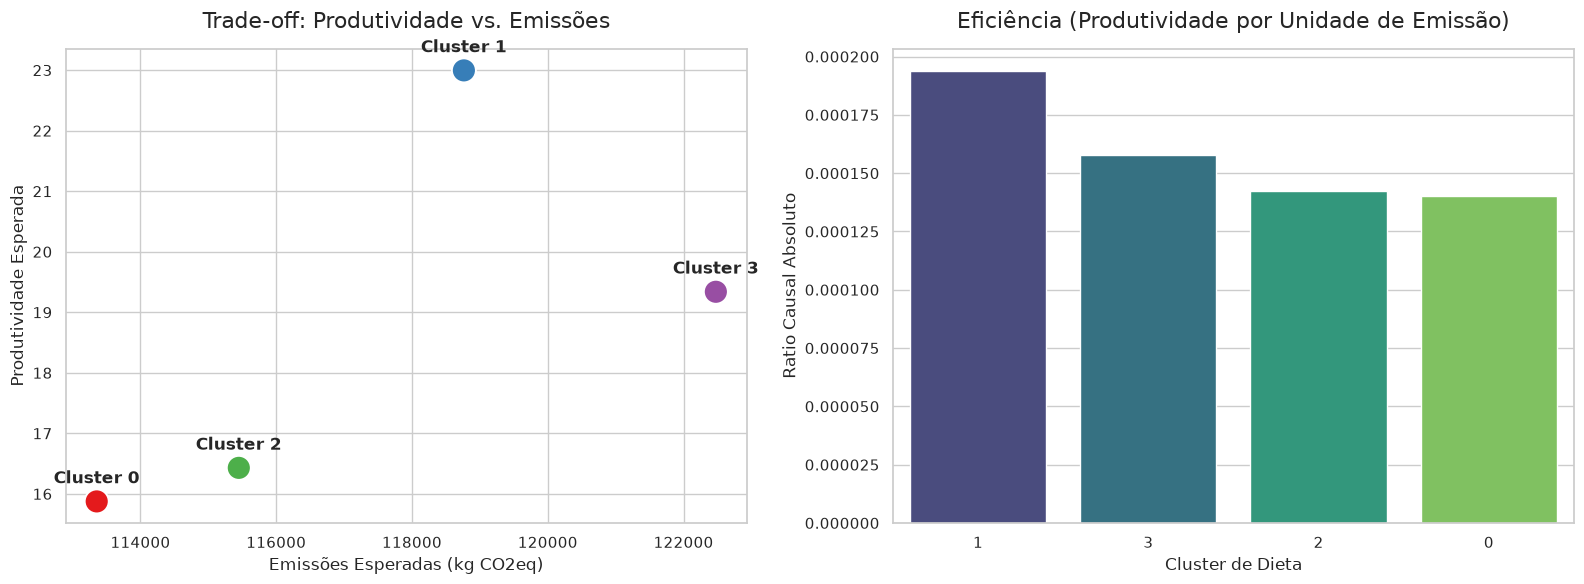

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transformando o dicionário bruto em um DataFrame do Pandas
df_results = pd.DataFrame(results).T
df_results.index.name = 'Cluster'
df_results.reset_index(inplace=True)

# Criando uma tabela bonita para impressão
print("--- RESUMO DO TRADE-OFF CAUSAL (CENÁRIOS ABSOLUTOS) ---")
display_df = df_results.copy()
display_df['Emissions'] = display_df['Emissions'].apply(lambda x: f"{x:,.2f} kg CO2eq")
display_df['Productivity'] = display_df['Productivity'].apply(lambda x: f"{x:,.2f}")
# Multiplicando o ratio por 10.000 para facilitar a leitura humana (ex: Litros por 10.000 kg CO2)
display_df['Ratio (x10k)'] = display_df['Ratio'].apply(lambda x: f"{x * 10000:.2f}") 
display_df = display_df.drop(columns=['Ratio'])
display(display_df)

# Plotagem dos Gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Dispersão (Trade-off de Pareto)
sns.scatterplot(
    data=df_results, x='Emissions', y='Productivity', 
    hue='Cluster', s=300, palette='Set1', ax=axes[0], legend=False
)
# Adicionando os rótulos nos pontos
for i in range(df_results.shape[0]):
    axes[0].text(
        df_results['Emissions'][i], df_results['Productivity'][i] + 0.3,
        f"Cluster {df_results['Cluster'][i]}", 
        horizontalalignment='center', weight='bold', fontsize=12
    )
axes[0].set_title("Trade-off: Produtividade vs. Emissões", fontsize=16, pad=15)
axes[0].set_xlabel("Emissões Esperadas (kg CO2eq)", fontsize=12)
axes[0].set_ylabel("Produtividade Esperada", fontsize=12)

# Gráfico 2: Gráfico de Barras do Ratio (O Vencedor)
df_results_sorted = df_results.sort_values(by='Ratio', ascending=False)
sns.barplot(
    data=df_results_sorted, x='Cluster', y='Ratio', 
    palette='viridis', ax=axes[1], order=df_results_sorted['Cluster']
)
axes[1].set_title("Eficiência (Produtividade por Unidade de Emissão)", fontsize=16, pad=15)
axes[1].set_xlabel("Cluster de Dieta", fontsize=12)
axes[1].set_ylabel("Ratio Causal Absoluto", fontsize=12)

plt.tight_layout()
plt.show()

In [18]:
print("Avaliando o impacto direto (intrínseco) da Dieta na Produtividade e nas Emissões...\n")

# Força da seta para as Emissões de Metano
arrow_strengths_emissions = gcm.arrow_strength(
    causal_model,
    target_node='co2_enteric_fermentation'
)
dietary_strategy_to_emissions_arrow = ('Dietary_Strategy_Cluster', 'co2_enteric_fermentation')
emissions_strength = arrow_strengths_emissions.get(dietary_strategy_to_emissions_arrow, 0)

# Força da seta para a Produtividade
arrow_strengths_prod = gcm.arrow_strength(
    causal_model,
    target_node='Productivity'
)
dietary_strategy_to_prod_arrow = ('Dietary_Strategy_Cluster', 'Productivity')
prod_strength = arrow_strengths_prod.get(dietary_strategy_to_prod_arrow, 0)

# Exibindo os Resultados Diretos da Dieta
print(f"Força Causal DIRETA da Dieta nas Emissões: {emissions_strength:.4f}")
print(f"Força Causal DIRETA da Dieta na Produtividade: {prod_strength:.4f}\n")

# --- COMPARATIVO (Opcional, mas excelente para o artigo) ---
print("-> O que mais influencia as Emissões DIRETAMENTE?")
for (source, dest), strength in sorted(arrow_strengths_emissions.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   {source}: {strength:.4f}")

print("\n-> O que mais influencia a Produtividade DIRETAMENTE?")
for (source, dest), strength in sorted(arrow_strengths_prod.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   {source}: {strength:.4f}")

Avaliando o impacto direto (intrínseco) da Dieta na Produtividade e nas Emissões...

Força Causal DIRETA da Dieta nas Emissões: 0.0000
Força Causal DIRETA da Dieta na Produtividade: 8.5266

-> O que mais influencia as Emissões DIRETAMENTE?
   Lactating_Cows: 7880816507.2266
   Heifers: 323169135.0703
   Calves: 112594507.7812
   Dry_Cows: 75551919.2188
   Lactating_Cows_Weight: 0.0000

-> O que mais influencia a Produtividade DIRETAMENTE?
   Dietary_Strategy_Cluster: 8.5266
